In [78]:
from dotenv import load_dotenv
load_dotenv()

True

In [79]:
from langgraph.graph import START,END, StateGraph
from langchain_groq import ChatGroq
from pydantic import BaseModel
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [80]:
llm= ChatGroq(model = "openai/gpt-oss-20b")

In [81]:
class MailState(BaseModel):
    query : str = ""
    draft : str = ""
    human_feedback : str = ""
    final_response : str = ""

In [82]:
## Defining the nodes

def DraftEmail(state:MailState) -> MailState:
    if state.human_feedback:
        draft = llm.invoke(f"""
                        Rewrite this draft email for {state.query}
                        You have generated this draft mail : {state.draft},
                        Human feedback to apply: {state.human_feedback}
                        """).content
    else:
        draft = llm.invoke(state.query).content
    state.draft = draft
    return state

def HumanFeedBack(state: MailState) -> MailState:
    feedback = interrupt({
        "draft_email": state.draft,
        "question":"Do you want to continue or re-write the mail"
    })

    fb= (feedback or "").strip().lower()
    if fb in ("approved","ok","yes"):
        state.human_feedback = ""
        return state
    else:
        state.human_feedback=feedback
        return state


def Finalize_Node(state:MailState)-> MailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        return state
    else:
        print("Email sent successfully")
        state.final_response = "Email sent successfully"
        return state

def condition_routing(state: MailState) -> Literal["draft","final"]:
    if state.human_feedback:
        return "draft"
    return "final"

In [83]:
graph_builder = StateGraph(MailState)

## node
graph_builder.add_node("draft", DraftEmail)
graph_builder.add_node("human_fb",HumanFeedBack)
graph_builder.add_node("final",Finalize_Node)

## EDGES
graph_builder.add_edge(START,"draft")
graph_builder.add_edge("draft","human_fb")
graph_builder.add_conditional_edges("human_fb",condition_routing)
graph_builder.add_edge("final",END)

#compile
graph=graph_builder.compile(checkpointer=InMemorySaver())

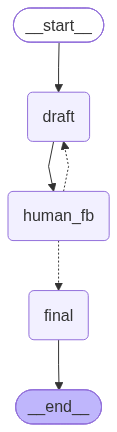

In [84]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [85]:
config = {"configurable":{"thread_id":1}}

In [86]:
res = graph.invoke({"query":"I want to send a email for medical"
                     "leave request,dates will be 2nd june to 5th june, so create a simple email."},
                     config=config)

In [87]:
res

{'query': 'I want to send a email for medicalleave request,dates will be 2nd june to 5th june, so create a simple email.',
 'draft': '**Subject:** Medical Leave Request – 2\u202f–\u202f5\u202fJune  \n\nDear [Supervisor’s Name],\n\nI am writing to inform you that I will need to take medical leave from **Monday, 2\u202fJune to Thursday, 5\u202fJune**. I will ensure that all urgent tasks are handed over and will be available via email for any critical questions.\n\nThank you for your understanding.\n\nBest regards,  \n[Your Name]  \n[Your Position]  \n[Your Contact Information]',
 'human_feedback': '',
 'final_response': '',
 '__interrupt__': [Interrupt(value={'draft_email': '**Subject:** Medical Leave Request – 2\u202f–\u202f5\u202fJune  \n\nDear [Supervisor’s Name],\n\nI am writing to inform you that I will need to take medical leave from **Monday, 2\u202fJune to Thursday, 5\u202fJune**. I will ensure that all urgent tasks are handed over and will be available via email for any critical

In [88]:
res = graph.invoke(Command(resume="I want to change the leave dates, and new dates are 4th june to 7th june and i want to remove the placeholders and just say thank you"), config=config)

In [89]:
print(res["draft"])

**Subject:** Medical Leave Request – 4 – 7 June  

Dear Supervisor,

I will be on medical leave from Monday, 4 June to Thursday, 7 June. I will ensure that all urgent tasks are handed over and will be available via email for any critical questions.

Thank you.


In [90]:
res

{'query': 'I want to send a email for medicalleave request,dates will be 2nd june to 5th june, so create a simple email.',
 'draft': '**Subject:** Medical Leave Request – 4\u202f–\u202f7\u202fJune  \n\nDear Supervisor,\n\nI will be on medical leave from Monday, 4\u202fJune to Thursday, 7\u202fJune. I will ensure that all urgent tasks are handed over and will be available via email for any critical questions.\n\nThank you.',
 'human_feedback': 'I want to change the leave dates, and new dates are 4th june to 7th june and i want to remove the placeholders and just say thank you',
 'final_response': '',
 '__interrupt__': [Interrupt(value={'draft_email': '**Subject:** Medical Leave Request – 4\u202f–\u202f7\u202fJune  \n\nDear Supervisor,\n\nI will be on medical leave from Monday, 4\u202fJune to Thursday, 7\u202fJune. I will ensure that all urgent tasks are handed over and will be available via email for any critical questions.\n\nThank you.', 'question': 'Do you want to continue or re-writ

In [91]:
res = graph.invoke(Command(resume="yes"), config=config)

Email sent successfully
